
# 🏠 House Prices: Advanced Regression Techniques

### A complete, beginner-friendly walkthrough from raw data to a Kaggle submission

This notebook is a start-to-finish guide for the classic Kaggle competition **["House Prices - Advanced Regression Techniques"](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)**. The goal of the competition is simple to state and surprisingly rich to solve well:

> **Predict the final sale price of a house in Ames, Iowa, using 79 explanatory variables describing (almost) every aspect of the property.**

Along the way you will learn — with plain-English explanations in markdown before every piece of code — how to:

1. Load and explore a real, messy, tabular dataset
2. Understand and transform a skewed target variable
3. Diagnose and handle missing data *thoughtfully* (not just by deleting rows!)
4. Engineer new features from raw columns
5. Encode categorical variables the right way (ordinal vs. one-hot)
6. Fix skewed numeric features
7. Train and evaluate a **Random Forest**
8. Train and evaluate **Gradient Boosting** models (sklearn, XGBoost, LightGBM)
9. Tune hyperparameters with `RandomizedSearchCV`
10. Interpret models with feature importance
11. Blend multiple models together
12. Generate a correctly formatted `submission.csv` file for Kaggle

No prior machine learning experience is assumed beyond "I've heard of it." Every new concept is explained in a markdown cell immediately before it's used in code.

---

## Table of Contents

1. [Setup and Imports](#setup)
2. [Getting the Data](#data)
3. [First Look at the Data](#firstlook)
4. [Understanding the Target Variable — SalePrice](#target)
5. [A Simple Baseline Model](#baseline)
6. [Exploratory Data Analysis (EDA)](#eda)
7. [Handling Outliers](#outliers)
8. [Combining Train and Test Sets](#combine)
9. [Handling Missing Data](#missing)
10. [Feature Engineering](#featureeng)
11. [Encoding Categorical Variables](#encoding)
12. [Fixing Skewed Numeric Features](#skew)
13. [Splitting Back Into Train/Test](#split)
14. [Creating a Validation Set](#valsplit)
15. [Model 1: Random Forest](#rf)
16. [Model 2: Gradient Boosting](#gbm)
17. [Comparing Models](#compare)
18. [Hyperparameter Tuning](#tuning)
19. [Feature Importance](#importance)
20. [Blending Models](#blending)
21. [Retraining on Full Data & Predicting on Test](#final)
22. [Creating the Submission File](#submission)
23. [Wrap-up & Next Steps](#wrapup)

---



<a id="setup"></a>
## 1. Setup and Imports

Before touching any data, we load the libraries we'll need. A quick guide to what each one does:

| Library | What it's for |
|---|---|
| `pandas` | Loading and manipulating tabular data (like Excel, but code-driven) |
| `numpy` | Fast numerical operations and array math |
| `matplotlib` / `seaborn` | Plotting and visualization |
| `scipy.stats` | Statistical functions — we'll use `skew` to measure how lopsided a distribution is |
| `sklearn` | The main machine learning library — models, preprocessing, evaluation metrics |

We also set a **random seed** everywhere we can. Many ML algorithms have a random component (e.g., how a Random Forest randomly samples data). Fixing the seed means that every time you re-run this notebook, you get *identical* results — which makes debugging and comparing experiments possible.


In [2]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import skew

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Make plots a bit nicer by default
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Show more rows/columns when we print DataFrames
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries loaded successfully.")


Libraries loaded successfully.



<a id="data"></a>
## 2. Getting the Data

This notebook is designed to run in **Google Colab**. You have three easy options for getting `train.csv` and `test.csv` into your Colab environment. Pick whichever is most convenient — **you only need to run ONE of the three code cells below.**

**Option A — Kaggle API (recommended, fastest for repeated use)**
1. Go to [kaggle.com](https://www.kaggle.com) → your profile picture → **Settings** → **API** → **Create New Token**. This downloads a file called `kaggle.json`.
2. Make sure you've joined the competition and accepted its rules at the [competition page](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/rules) — Kaggle will refuse to download the data otherwise.
3. Run the Option A cell below and upload `kaggle.json` when prompted.

**Option B — Manual upload**
If you've already downloaded `train.csv` and `test.csv` to your computer (e.g., from the [competition Data tab](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)), just run the Option B cell and select both files.

**Option C — Google Drive**
If you've saved the CSVs in your Google Drive, mount your Drive and point the paths to wherever you saved them.


In [7]:
DATA_DIR = './house_prices_data'
os.makedirs(DATA_DIR, exist_ok=True)

!gdown --id 1nuWyyGGsncxmBkJFmvKFW-_t2YuEJAHY -O {DATA_DIR}/train.csv
!gdown --id 1RJZ_DrnzpiLnMJQjvbnt4NnQ50ap88oo -O {DATA_DIR}/test.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1nuWyyGGsncxmBkJFmvKFW-_t2YuEJAHY
To: /content/house_prices_data/train.csv
100% 461k/461k [00:00<00:00, 110MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1RJZ_DrnzpiLnMJQjvbnt4NnQ50ap88oo
To: /content/house_prices_data/test.csv
100% 451k/451k [00:00<00:00, 89.3MB/s]


In [8]:

# ============================================================
# Load the data
# ============================================================
# By default we assume the files are in the current directory. Change DATA_DIR
# above if you used Option A or Option C.

import os
if 'DATA_DIR' not in dir():
    DATA_DIR = '.'

train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")


Train shape: (1460, 81)
Test shape:  (1459, 80)



<a id="firstlook"></a>
## 3. First Look at the Data

Before doing anything else, always look at your raw data. Three quick checks give you a huge amount of orientation:

- `.head()` — see the first few rows, column names, and what values look like
- `.shape` — how many rows (houses) and columns (features) you have
- `.info()` / `.dtypes` — data types per column (numbers vs. text) and non-null counts

The training set has one extra column compared to the test set: **`SalePrice`** — that's the target we're trying to predict. The whole point of the competition is to predict `SalePrice` for every house in `test.csv`.


In [9]:

train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:

test.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [11]:

print("Columns only in train (should just be the target):")
print(set(train.columns) - set(test.columns))

print("\nData types breakdown:")
print(train.dtypes.value_counts())

print("\nQuick statistical summary of numeric columns:")
train.describe()


Columns only in train (should just be the target):
{'SalePrice'}

Data types breakdown:
object     43
int64      35
float64     3
Name: count, dtype: int64

Quick statistical summary of numeric columns:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



Each column is explained in **`data_description.txt`**, which comes bundled with the competition data. Reading it carefully is one of the highest-value things you can do in this competition — it tells you, for example, that a missing value (`NaN`) in `PoolQC` doesn't mean "unknown," it means **"this house has no pool."** We'll lean on this file heavily in the missing-data section below.

Next, we handle the `Id` column. It's just a row identifier with no predictive meaning — but we need to keep it around so we can label our final predictions correctly. We'll save it separately and drop it from the feature set.


In [12]:

train_ID = train['Id']
test_ID = test['Id']

train.drop('Id', axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)

print("Id column removed from both train and test feature sets (saved separately for later).")


Id column removed from both train and test feature sets (saved separately for later).



<a id="target"></a>
## 4. Understanding the Target Variable — SalePrice

`SalePrice` is what we're trying to predict, so understanding its distribution is critical. Two things we care about:

1. **Shape of the distribution.** Many real-world quantities like prices, incomes, and populations are *right-skewed* — most values cluster at the low-to-middle end, with a long tail of expensive outliers. Linear models assume roughly normal (bell-curve) residuals, so a heavily skewed target can hurt them.
2. **The competition's evaluation metric.** Kaggle scores this competition using the **Root Mean Squared Error (RMSE) between the *logarithm* of the predicted price and the *logarithm* of the actual price.** This is not just a modeling nicety — it's literally what you're being graded on. Scoring on the log of price also makes sense intuitively: being off by \$20,000 matters a lot more for a \$100,000 starter home than for a \$700,000 mansion, and the log transform naturally accounts for that by measuring *relative* rather than *absolute* error.

Because of point 2, we will train our models to predict `log(1 + SalePrice)` rather than raw `SalePrice`. We use `log1p` (i.e., `log(1+x)`) instead of a plain `log` because it safely handles a value of 0 (`log(0)` is undefined, `log1p(0) = 0`). At prediction time we simply reverse the transform with `expm1` (i.e., `exp(x) - 1`) to get back to dollars.


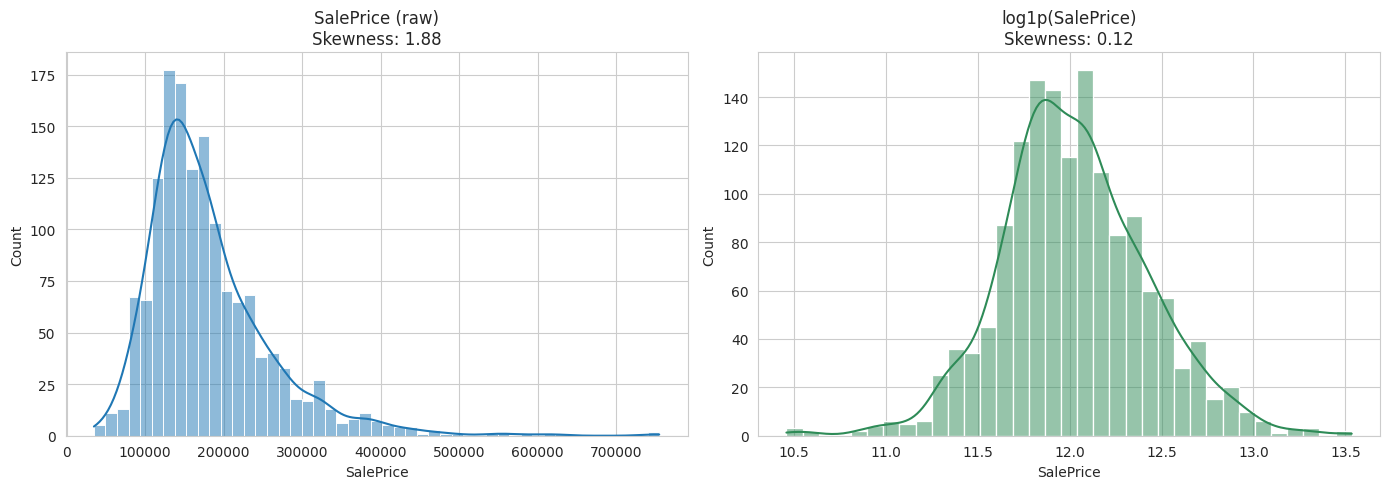

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title(f"SalePrice (raw)\nSkewness: {train['SalePrice'].skew():.2f}")

log_price = np.log1p(train['SalePrice'])
sns.histplot(log_price, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f"log1p(SalePrice)\nSkewness: {log_price.skew():.2f}")

plt.tight_layout()
plt.show()



Notice how the raw `SalePrice` distribution has a long right tail (skewness clearly positive), while `log1p(SalePrice)` looks much closer to a symmetric bell curve (skewness near 0). This confirms the log transform is a good idea — and conveniently, it also matches the metric we're being scored on.

From this point forward, whenever we train a model we will train it on `log1p(SalePrice)`, and whenever we want to interpret predictions in dollars (or write the submission file) we will apply `expm1` to convert back.



<a id="baseline"></a>
## 5. A Simple Baseline Model

Before building anything fancy, it's good practice to establish a **baseline** — the simplest reasonable model you can build. A baseline gives you a number to beat, and it stops you from being fooled into thinking a complicated model is "good" when it's barely better than something trivial.

Conveniently, the competition tells us exactly what a naive baseline looks like: the file `sample_submission.csv` is described as *"a benchmark submission from a linear regression on year and month of sale, lot square footage, and number of bedrooms."* Let's reproduce that idea ourselves so we have an honest number to compare against later.


In [14]:

baseline_features = ['YrSold', 'MoSold', 'LotArea', 'BedroomAbvGr']

X_base = train[baseline_features]
y_base = np.log1p(train['SalePrice'])

X_base_train, X_base_val, y_base_train, y_base_val = train_test_split(
    X_base, y_base, test_size=0.2, random_state=RANDOM_SEED
)

baseline_model = LinearRegression()
baseline_model.fit(X_base_train, y_base_train)
baseline_pred = baseline_model.predict(X_base_val)

baseline_rmse = np.sqrt(mean_squared_error(y_base_val, baseline_pred))
print(f"Baseline (4-feature linear regression) validation RMSE (log scale): {baseline_rmse:.4f}")


Baseline (4-feature linear regression) validation RMSE (log scale): 0.4072



Keep this number in mind — every model we build from here on should beat it by a wide margin, since we'll be using all 79 features plus engineered ones instead of just 4. If a fancy model *doesn't* clearly beat this baseline, that's a signal something went wrong upstream (e.g., a data leak or a bug), not that the extra features weren't helpful.



<a id="eda"></a>
## 6. Exploratory Data Analysis (EDA)

Now let's explore relationships between features and the target. EDA (Exploratory Data Analysis) is the process of visualizing and summarizing data to build intuition *before* modeling — it often reveals data quality issues, strong predictors, and outliers that need special handling.

### 6.1 Which numeric features correlate most with SalePrice?

The **correlation coefficient** measures how strongly two numeric variables move together, ranging from -1 (perfectly opposite) to +1 (perfectly aligned). It's a quick way to shortlist promising features.


In [16]:

numeric_train = train.select_dtypes(include=[np.number])
correlations = numeric_train.corr()['SalePrice'].sort_values(ascending=False)

print("Top 15 features most positively correlated with SalePrice:")
print(correlations.head(15))


Top 15 features most positively correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


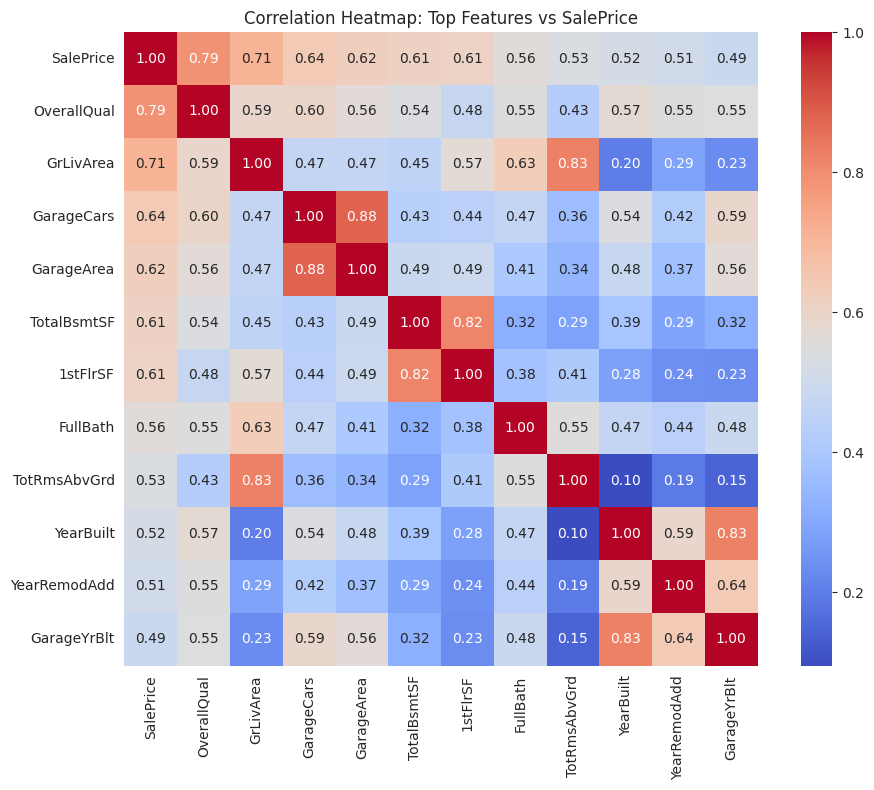

In [17]:

top_corr_features = correlations.head(12).index

plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap: Top Features vs SalePrice')
plt.tight_layout()
plt.show()



`OverallQual` (overall material/finish quality, rated 1-10) and `GrLivArea` (above-ground living area in square feet) usually turn out to be two of the strongest single predictors of house price — which matches common sense: bigger, better-built houses cost more. Let's look at those two relationships directly with scatter plots.


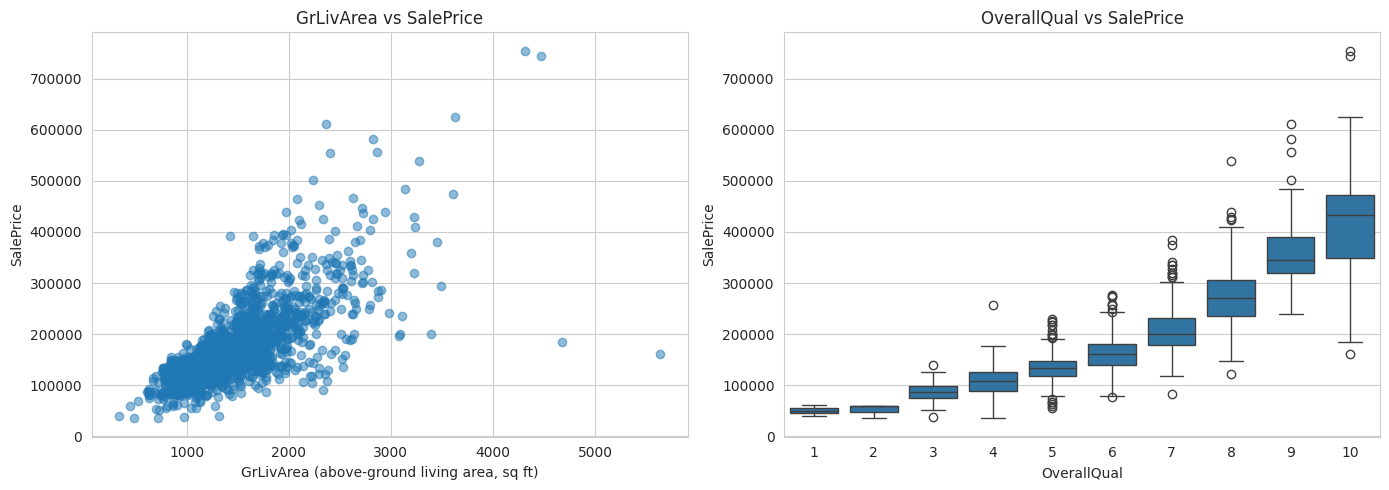

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5)
axes[0].set_xlabel('GrLivArea (above-ground living area, sq ft)')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('GrLivArea vs SalePrice')

sns.boxplot(x='OverallQual', y='SalePrice', data=train, ax=axes[1])
axes[1].set_title('OverallQual vs SalePrice')

plt.tight_layout()
plt.show()



The `GrLivArea` scatter plot shows a mostly clear upward trend — bigger houses sell for more — but look closely at the bottom-right of the plot. There are a couple of houses with **huge living area (>4000 sq ft) but surprisingly low sale price**. These are almost certainly unusual sales (e.g., distressed sales, partial sales) rather than representative examples of "big house = expensive house." Points like these are exactly what we check for in the next step: **outlier handling**.



<a id="outliers"></a>
## 7. Handling Outliers

An **outlier** is a data point that doesn't follow the general pattern of the rest of the data. Outliers aren't automatically "bad" — sometimes they're the most interesting rows in your dataset — but when a handful of unusual points can badly distort a model trained to minimize squared error (which punishes big misses heavily), it's often worth removing them, *as long as you have good reason to believe they're not representative of the population you're trying to predict on.*

Based on the scatter plot above, we'll remove the well-known extreme cases in this dataset: houses with `GrLivArea > 4000` sq ft but `SalePrice < 300,000`. These are widely documented (including by the dataset's original author) as unusual sales that hurt model performance without teaching anything generalizable.

**A word of caution for beginners:** outlier removal should be used sparingly and only on the *training* set. Never remove rows from the *test* set — you must always produce a prediction for every single test row, no matter how unusual it looks, since that's what the competition grades you on.


In [19]:

print(f"Rows before outlier removal: {train.shape[0]}")

train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]
train = train.reset_index(drop=True)

print(f"Rows after outlier removal:  {train.shape[0]}")


Rows before outlier removal: 1460
Rows after outlier removal:  1458



<a id="combine"></a>
## 8. Combining Train and Test Sets

Here's a practical challenge: whatever cleaning, encoding, and feature engineering steps we apply, we need to apply **the exact same steps, in the exact same way, to both train and test.** If a category like `Neighborhood == 'Blueste'` only appears in the training set, one-hot encoding train and test *separately* would create mismatched columns and break our model.

The standard, simple solution: **temporarily stack train and test into one combined DataFrame**, do all the cleaning/encoding on the combined data, and then split it back apart right before modeling. We first pull the target (`SalePrice`) out of `train` (log-transformed, as decided above) so it doesn't get mixed into the feature-processing steps, since `test` has no `SalePrice` column to match against.

**A note for the curious:** this "combine everything" approach is common and convenient for a first pass, but it does mean a few of our preprocessing choices (like filling in a missing value with a median) are computed using information from the test set too. In strict "no leakage" machine learning practice — especially outside of Kaggle, where new data truly hasn't been seen yet — you'd fit those choices on training data only. For this competition, since we're combining two static, already-collected files, the practical impact is minimal, and it keeps the notebook far simpler. It's worth remembering the distinction as you tackle future projects with genuinely unseen future data.


In [20]:

y = np.log1p(train['SalePrice'])
train_features = train.drop('SalePrice', axis=1)

n_train = train_features.shape[0]
n_test = test.shape[0]

all_data = pd.concat([train_features, test]).reset_index(drop=True)

print(f"Combined data shape: {all_data.shape}")
print(f"(That's {n_train} train rows + {n_test} test rows = {n_train + n_test} total)")


Combined data shape: (2917, 79)
(That's 1458 train rows + 1459 test rows = 2917 total)



<a id="missing"></a>
## 9. Handling Missing Data

This is one of the most important — and most misunderstood — steps in this competition. Let's start by seeing how much missing data we actually have.


              MissingCount  MissingPercent
PoolQC                2908       99.691464
MiscFeature           2812       96.400411
Alley                 2719       93.212204
Fence                 2346       80.425094
MasVnrType            1766       60.541652
FireplaceQu           1420       48.680151
LotFrontage            486       16.660953
GarageQual             159        5.450806
GarageYrBlt            159        5.450806
GarageCond             159        5.450806
GarageFinish           159        5.450806
GarageType             157        5.382242
BsmtExposure            82        2.811107
BsmtCond                82        2.811107
BsmtQual                81        2.776826
BsmtFinType2            80        2.742544
BsmtFinType1            79        2.708262
MasVnrArea              23        0.788481
MSZoning                 4        0.137127
BsmtFullBath             2        0.068564
Functional               2        0.068564
BsmtHalfBath             2        0.068564
Utilities  

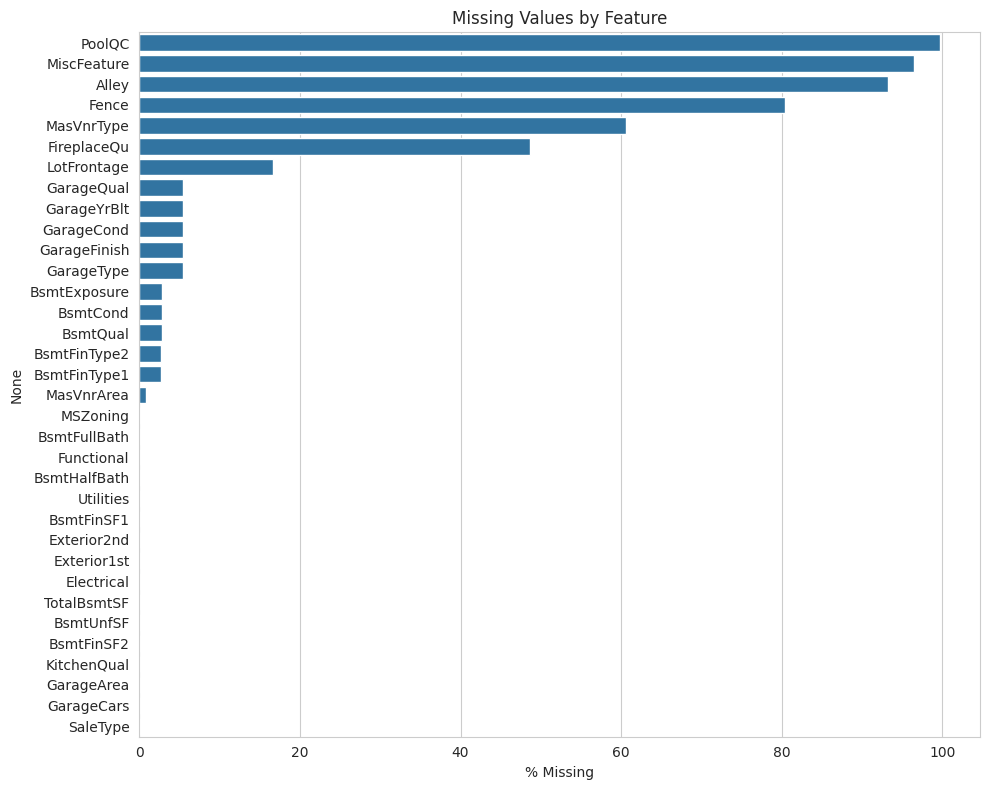

In [21]:

missing = all_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(all_data)) * 100

missing_df = pd.DataFrame({'MissingCount': missing, 'MissingPercent': missing_pct})
print(missing_df)

plt.figure(figsize=(10, 8))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.xlabel('% Missing')
plt.title('Missing Values by Feature')
plt.tight_layout()
plt.show()



That looks alarming — some columns are "missing" 90%+ of their values! But here's the key insight that `data_description.txt` reveals: **for most of these columns, `NaN` doesn't mean "the value is unknown" — it means "this feature doesn't apply to this house."** For example:

- `PoolQC` is `NaN` for a house **because it has no pool**, not because someone forgot to record its pool quality.
- `Alley` is `NaN` for a house with no alley access.
- `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond` are `NaN` for houses **with no garage.**
- `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` are `NaN` for houses **with no basement.**
- `FireplaceQu` is `NaN` for houses with no fireplace.

Blindly dropping these columns (because "90% missing!") would throw away real, useful information. Instead, we fill these with a sentinel value that means "not applicable": the string `'None'` for categorical columns, or `0` for the numeric ones (e.g., a house with no garage has `GarageArea = 0`).

A **separate, smaller** group of columns has *genuinely* missing values — a handful of rows where the value is simply unknown (e.g., someone's `Electrical` system wasn't recorded). For these, we fill with the most common value (the **mode**) or a reasonable default, since there are too few missing rows to justify anything fancier.

Let's handle each group explicitly and deliberately, rather than using one generic `.fillna()` call for everything.



### 9.1 "Missing means None" — categorical features

These columns are missing specifically because the underlying feature doesn't exist for that house.


In [22]:

none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

print(f"Filled {len(none_cols)} categorical columns with 'None'.")


Filled 15 categorical columns with 'None'.



### 9.2 "Missing means zero" — numeric features

Similarly, if a house has no garage, `GarageArea` and `GarageCars` should be `0`, not "unknown." Same logic for basement square footage and bathroom counts.


In [23]:

zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

print(f"Filled {len(zero_cols)} numeric columns with 0.")


Filled 10 numeric columns with 0.



### 9.3 `LotFrontage` — a special case

`LotFrontage` (linear feet of street connected to the property) is missing for about 16% of houses, and unlike the columns above, there's no reason to think a missing value here means "zero street frontage." It's more likely the value simply wasn't recorded.

A reasonable guess is that houses in the **same neighborhood** tend to have similar lot frontages (since neighborhoods are often built with similar lot layouts). So instead of filling with one global number, we fill each missing value with the **median `LotFrontage` of houses in the same neighborhood** — a more locally-informed guess than a single dataset-wide average.


In [24]:

all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Safety net: if an entire neighborhood group had no LotFrontage values at all
# (unlikely, but possible in small test sets), fall back to the overall median.
all_data['LotFrontage'] = all_data['LotFrontage'].fillna(all_data['LotFrontage'].median())

print("LotFrontage missing values remaining:", all_data['LotFrontage'].isnull().sum())


LotFrontage missing values remaining: 0



### 9.4 Truly missing categorical values — fill with the mode

A few categorical columns have only a tiny number of missing values (often just 1-2 rows, usually in the test set) where there's no special "None" meaning — the data is simply incomplete. For these, filling with the **mode** (most frequently occurring category) is a simple, sensible default.


In [25]:

mode_fill_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']

for col in mode_fill_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(f"Filled {len(mode_fill_cols)} columns with their mode.")


Filled 6 columns with their mode.



### 9.5 `Functional` and `Utilities` — special rules from the data dictionary

`data_description.txt` explicitly states that for `Functional`, **"typical unless deductions are warranted"** — in other words, missing `Functional` should be filled with `'Typ'` (typical), not the mode (which happens to also be `'Typ'` here, but it's worth encoding the *reason*, not just the coincidence).

`Utilities` is a different story: in this dataset nearly every house has the same value (`'AllPub'`), making the column almost useless for distinguishing houses — and if the rare category present in one split doesn't also appear in the other, it can even break one-hot encoding alignment. We simply drop it.


In [26]:

all_data['Functional'] = all_data['Functional'].fillna('Typ')
all_data = all_data.drop('Utilities', axis=1)

print("Functional missing values filled with 'Typ'; Utilities column dropped.")


Functional missing values filled with 'Typ'; Utilities column dropped.



### 9.6 Final check — are there any missing values left?


In [27]:

remaining_missing = all_data.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if remaining_missing.empty:
    print("No missing values remain. All clear!")
else:
    print("Columns still containing missing values:")
    print(remaining_missing)


No missing values remain. All clear!



<a id="featureeng"></a>
## 10. Feature Engineering

**Feature engineering** means creating new columns from the existing raw data that make patterns easier for a model to learn. This is often where the biggest performance gains in a Kaggle competition come from — arguably more than model choice or tuning. A few guiding ideas we'll apply here:

- **Combine related columns.** A house's total living space is spread across `TotalBsmtSF`, `1stFlrSF`, and `2ndFlrSF`. Adding them into one `TotalSF` feature can be more informative than three separate ones, since total square footage is often what buyers actually care about.
- **Turn raw dates into meaningful ages.** `YearBuilt` on its own is just a year; `HouseAge = YrSold - YearBuilt` tells the model directly how old the house was *at the time it was sold*, which is usually a more directly useful signal.
- **Create simple yes/no indicator flags.** Whether a house has a pool at all is a stronger, cleaner signal than the exact pool square footage, since pools are rare and their exact size matters less than whether one exists.
- **Combine correlated counts sensibly.** Full bathrooms and half bathrooms both add value, but a half-bath isn't worth as much as a full one — so we combine them with a weight (`0.5`) into a single `TotalBathrooms` feature.


In [28]:

# Total square footage across basement + 1st floor + 2nd floor
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# Age-based features: how old was the house / how long since remodeling, at time of sale
all_data['HouseAge'] = all_data['YrSold'].astype(int) - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'].astype(int) - all_data['YearRemodAdd']
all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)

# Combine full + half baths (weighting half baths as 0.5)
all_data['TotalBathrooms'] = (
    all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
    all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath']
)

# Simple "has this amenity at all" flags
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)

# Total porch/deck area across all porch-related columns
all_data['TotalPorchSF'] = (
    all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
    all_data['3SsnPorch'] + all_data['ScreenPorch'] + all_data['WoodDeckSF']
)

print("Added 10 new engineered features. New shape:", all_data.shape)


Added 10 new engineered features. New shape: (2917, 88)



> **Tip for going further:** feature engineering is iterative. After you get a working model and look at its feature importances (see Section 19), you'll often notice patterns worth encoding explicitly as new features — like interaction terms (`OverallQual * GrLivArea`) or neighborhood-level average prices. Treat this section as a starting point, not a finished product.



<a id="encoding"></a>
## 11. Encoding Categorical Variables

Machine learning models need numbers, not text — so every categorical (text) column needs to become numeric before we can train on it. There are two fundamentally different kinds of categorical variables in this dataset, and they should be encoded differently:

### 11.1 Ordinal features — categories with a natural order

Columns like `KitchenQual` (kitchen quality) have values `Excellent > Good > Typical/Average > Fair > Poor`. There's a clear ranking here, and we want our model to see that "Excellent" is "better than" "Good," which is "better than" "Typical." We do this with **ordinal encoding**: mapping each category to a number that preserves the order (e.g., `Ex=5, Gd=4, TA=3, Fa=2, Po=1`, and `None=0` for "not applicable," using the fill values from Section 9).


In [29]:

qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

ordinal_qual_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond'
]

for col in ordinal_qual_cols:
    all_data[col] = all_data[col].map(qual_map)

print(f"Ordinally encoded {len(ordinal_qual_cols)} quality-scale columns.")
all_data[ordinal_qual_cols].head()


Ordinally encoded 9 quality-scale columns.


,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond
0,4,3,4,3,5,4,0,3,3
1,3,3,4,3,5,3,3,3,3
2,4,3,4,3,5,4,3,3,3
3,3,3,3,4,4,4,4,3,3
4,4,3,4,3,5,4,3,3,3



### 11.2 Nominal features — categories with no inherent order

Columns like `Neighborhood` or `RoofStyle` have no natural ranking — `'Gable'` isn't "more" or "less" than `'Hip'`, they're just different categories. Assigning arbitrary numbers here (e.g., `Gable=1, Hip=2`) would trick the model into thinking there's a meaningful order and distance between them where none exists. Instead, we use **one-hot encoding**: creating a separate 0/1 column for each category (handled with `pd.get_dummies` later in Section 12).

### 11.3 A subtlety: some "numbers" are actually categories

`MSSubClass` (the type of dwelling, e.g., "20 = 1-story 1946 & newer") is stored as a number, but it's really a category code — there's no meaningful sense in which building-class `120` is "six times" building-class `20`. Same story for `MoSold` and `YrSold` when we want the model to learn "some months/years tend to have different typical prices" as a category effect rather than a straight-line numeric trend. We convert these to strings so `pd.get_dummies` treats them as categorical rather than continuous.


In [31]:

categorical_but_numeric_cols = ['MSSubClass', 'MoSold', 'YrSold']

for col in categorical_but_numeric_cols:
    all_data[col] = all_data[col].astype(str)

print("Converted MSSubClass, MoSold, YrSold to string type so they'll be one-hot encoded, not treated as continuous numbers.")


Converted MSSubClass, MoSold, YrSold to string type so they'll be one-hot encoded, not treated as continuous numbers.



<a id="skew"></a>
## 12. Fixing Skewness in Numeric Features

Just like `SalePrice` itself, many numeric predictor columns (like `LotArea` or `TotalBsmtSF`) are right-skewed — a few enormous lots or basements stretch the distribution out. We measured skewness earlier with `scipy.stats.skew`; a value near 0 means roughly symmetric, and values much greater than about **0.75** (a common rule-of-thumb threshold) indicate meaningful skew.

Tree-based models (Random Forest, Gradient Boosting) are fairly insensitive to skewed inputs, since they split on thresholds rather than assuming linear relationships — so this step matters less for them. But it's cheap, doesn't hurt tree models, and *does* matter a lot if you ever want to try a linear model (like Ridge or Lasso regression) on the same features. We apply the same `log1p` trick we used on the target to any numeric feature above the skewness threshold.

One deliberate exception: we skip our own binary 0/1 flag columns (`HasPool`, `HasGarage`, `HasFireplace`, `Has2ndFloor`, `IsRemodeled`) and `GarageYrBlt`. "Skewness" isn't a meaningful concept for a yes/no flag — it just reflects how rare or common that value is, not a shape a log transform would sensibly "fix" — and log-transforming a raw year value doesn't have a clean real-world interpretation either. We only want this step touching genuinely continuous, meaningfully-skewed measurements like square footage or lot area.


In [32]:

# Columns to exclude from the automatic skew-fixing step (see explanation above)
skew_exclude_cols = ['HasPool', 'HasGarage', 'HasFireplace', 'Has2ndFloor', 'IsRemodeled', 'GarageYrBlt']

numeric_feats = all_data.select_dtypes(include=[np.number]).columns
numeric_feats = [c for c in numeric_feats if c not in skew_exclude_cols]

skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]

print(f"Found {len(high_skew)} numeric features with |skewness| > 0.75:")
print(high_skew)

for feat in high_skew.index:
    # log1p requires non-negative input; shift if a column happens to contain negatives
    if all_data[feat].min() < 0:
        all_data[feat] = np.log1p(all_data[feat] - all_data[feat].min())
    else:
        all_data[feat] = np.log1p(all_data[feat])

print(f"\nApplied log1p transform to {len(high_skew)} skewed features.")


Found 27 numeric features with |skewness| > 0.75:
MiscVal          21.939672
PoolArea         17.688664
LotArea          13.109495
LowQualFinSF     12.084539
3SsnPorch        11.372080
KitchenAbvGr      4.300550
BsmtFinSF2        4.144503
EnclosedPorch     4.002344
ScreenPorch       3.945101
BsmtHalfBath      3.929996
MasVnrArea        2.621719
OpenPorchSF       2.529358
WoodDeckSF        1.844792
TotalPorchSF      1.379521
ExterCond         1.315069
1stFlrSF          1.257286
LotFrontage       1.103039
GrLivArea         1.068750
TotalSF           1.009157
BsmtFinSF1        0.980645
BsmtUnfSF         0.919688
2ndFlrSF          0.861556
ExterQual         0.783456
BsmtQual         -1.271611
GarageQual       -3.262260
GarageCond       -3.381673
BsmtCond         -3.602661
dtype: float64

Applied log1p transform to 27 skewed features.



<a id="split"></a>



## 13. One-Hot Encoding the Remaining Categorical Columns

Now we convert all remaining text (nominal categorical) columns into 0/1 dummy columns with `pd.get_dummies`. Because we combined train and test back in Section 8, every category that appears in *either* set will get its own column consistently across both — this is exactly the alignment problem we combined the data to avoid.

Note that our dataset will get noticeably wider here (more columns) since, for example, `Neighborhood`'s ~25 categories become ~25 separate 0/1 columns. This is completely normal and expected, and tree-based models handle wide, sparse, one-hot-encoded data just fine.


In [33]:

print(f"Shape before one-hot encoding: {all_data.shape}")

all_data = pd.get_dummies(all_data)

print(f"Shape after one-hot encoding:  {all_data.shape}")


Shape before one-hot encoding: (2917, 88)
Shape after one-hot encoding:  (2917, 302)



## 14. Splitting Back Into Train and Test Sets

All our cleaning, feature engineering, and encoding has been done on the combined `all_data` DataFrame. Now it's time to split it back into the original train/test pieces, using the row counts we saved back in Section 8 (`n_train` and `n_test`) — the first `n_train` rows are our original training data, and everything after that is test data.


In [34]:

X = all_data.iloc[:n_train, :].reset_index(drop=True)
X_test = all_data.iloc[n_train:, :].reset_index(drop=True)

print(f"X (training features):      {X.shape}")
print(f"y (training target):        {y.shape}")
print(f"X_test (test features):     {X_test.shape}")

assert X.shape[0] == y.shape[0], "Mismatch between X and y row counts!"
assert list(X.columns) == list(X_test.columns), "Train/test columns don't match!"
print("\nSanity checks passed: X and y have matching rows, and X/X_test have matching columns.")


X (training features):      (1458, 302)
y (training target):        (1458,)
X_test (test features):     (1459, 302)

Sanity checks passed: X and y have matching rows, and X/X_test have matching columns.



<a id="valsplit"></a>
## 15. Creating a Validation Set

Here's a problem: `test.csv` has no `SalePrice` column (that's literally what you're being asked to predict!), so we can't use it to check how good our model is *while we're developing it*. If we only ever tested our ideas by submitting to Kaggle, we'd be limited to a handful of submissions per day and would be optimizing blind for everything in between.

The standard solution is to carve out part of our own labeled training data as a **validation set** — data our model never trains on, so we can honestly estimate how well it will generalize to the real test set. We'll use an 80/20 split: 80% of the training rows to fit the model, 20% held out purely to evaluate it.


In [35]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")


X_train: (1166, 302)  |  X_val: (292, 302)



Throughout the modeling sections below, we'll fit on `X_train`/`y_train` and score on `X_val`/`y_val`. This gives us an RMSE number, in the same log-price units the competition itself uses, that we can trust to reflect real generalization performance — well before we ever touch the actual Kaggle test set.



<a id="rf"></a>
## 16. Model 1: Random Forest Regressor

### What is a Random Forest?

A single **decision tree** predicts by asking a sequence of yes/no questions about the features (e.g., "Is `OverallQual` > 6? If yes, is `GrLivArea` > 1500?...") until it reaches a final prediction. Individual trees are easy to interpret but tend to **overfit** — they memorize quirks of the training data and generalize poorly.

A **Random Forest** fixes this by training many trees (say, 100-500) and averaging their predictions. Two sources of randomness keep the trees diverse from each other:
1. Each tree is trained on a random *bootstrap sample* (random sample with replacement) of the training rows.
2. Each split within a tree only considers a random subset of features, not all of them.

The intuition: **asking many semi-independent "experts" and averaging their opinions** tends to cancel out individual mistakes, producing a more stable, accurate prediction than any single expert (tree) alone. This general strategy — averaging many high-variance models to reduce variance — is called **bagging** (bootstrap aggregating).

A convenient practical bonus: Random Forests need almost no preprocessing tuning. They're insensitive to feature scale (no need to standardize/normalize numbers) and handle both numeric and one-hot-encoded categorical inputs well — which is exactly the kind of data we've prepared.


In [36]:

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=RANDOM_SEED,
    n_jobs=-1  # use all available CPU cores
)

rf_model.fit(X_train, y_train)
rf_val_pred = rf_model.predict(X_val)

rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
print(f"Random Forest validation RMSE (log scale): {rf_rmse:.4f}")
print(f"(Baseline linear regression was: {baseline_rmse:.4f})")


Random Forest validation RMSE (log scale): 0.1439
(Baseline linear regression was: 0.4072)



### Cross-validation: a more robust performance estimate

A single 80/20 split gives one estimate of performance, but that estimate depends somewhat on *which* 20% happened to land in the validation set. **K-fold cross-validation** gives a more robust estimate: split the training data into *K* equal folds (commonly 5), train on *K-1* of them and validate on the remaining fold, then repeat *K* times so every fold gets a turn as the validation set. Averaging the *K* resulting scores smooths out the luck of any single split.


In [37]:

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv_scores = np.sqrt(-cross_val_score(
    rf_model, X, y, scoring='neg_mean_squared_error', cv=kf, n_jobs=-1
))

print(f"5-fold CV RMSE scores: {np.round(cv_scores, 4)}")
print(f"Mean CV RMSE: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")


5-fold CV RMSE scores: [0.1438 0.1265 0.1402 0.1368 0.1301]
Mean CV RMSE: 0.1355  (+/- 0.0064)



<a id="gbm"></a>
## 17. Model 2: Gradient Boosting

### What is Gradient Boosting?

Random Forests build many trees **independently** (in parallel) and average them. **Gradient Boosting** takes a different approach: it builds trees **sequentially**, where each new tree is trained specifically to correct the mistakes (residual errors) made by the ensemble so far. Roughly:

1. Start with a simple initial prediction (e.g., the average `SalePrice`).
2. Compute the residual errors — how far off the current predictions are.
3. Train a new, typically shallow tree to predict those residual errors.
4. Add a small, scaled-down fraction of that tree's predictions to the running total (the **learning rate** controls how much each tree is allowed to contribute).
5. Repeat steps 2-4 for many rounds, each new tree focusing on whatever error remains.

This sequential error-correction often produces higher accuracy than Random Forests, but comes with a real trade-off: because each tree is deliberately fit to the *previous* errors, gradient boosting is more prone to **overfitting** if you use too many trees, too high a learning rate, or trees that are too deep — careful tuning (Section 18) matters more here than for Random Forests.

### Which implementation should I use?

- **`sklearn.ensemble.GradientBoostingRegressor`** — built into scikit-learn, no extra installation, a great way to learn the algorithm, but slower on larger datasets.
- **XGBoost** and **LightGBM** — external libraries, both extremely popular on Kaggle, both dramatically faster than sklearn's implementation (via clever engineering like histogram-based splitting) and often slightly more accurate out of the box. Colab has internet access, so installing them takes seconds.

We'll train all three so you can see they all follow the exact same `fit` / `predict` pattern despite their different backends — and so you can compare their results directly.


In [38]:

gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_SEED
)

gbr_model.fit(X_train, y_train)
gbr_val_pred = gbr_model.predict(X_val)

gbr_rmse = np.sqrt(mean_squared_error(y_val, gbr_val_pred))
print(f"sklearn GradientBoostingRegressor validation RMSE (log scale): {gbr_rmse:.4f}")


sklearn GradientBoostingRegressor validation RMSE (log scale): 0.1178


In [39]:

# Install XGBoost and LightGBM (fast, only needs to run once per Colab session)
!pip install -q xgboost lightgbm


In [40]:

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_val_pred = xgb_model.predict(X_val)

xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
print(f"XGBoost validation RMSE (log scale): {xgb_rmse:.4f}")


XGBoost validation RMSE (log scale): 0.1137


In [41]:

from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)
lgbm_val_pred = lgbm_model.predict(X_val)

lgbm_rmse = np.sqrt(mean_squared_error(y_val, lgbm_val_pred))
print(f"LightGBM validation RMSE (log scale): {lgbm_rmse:.4f}")


LightGBM validation RMSE (log scale): 0.1225



<a id="compare"></a>
## 18. Comparing Models

Let's line up every model's validation RMSE side by side. Remember: **lower is better** (we're measuring error, and this is on the log-price scale that matches the competition's own metric).


                         Model  Validation RMSE
0                      XGBoost         0.113660
1  Gradient Boosting (sklearn)         0.117774
2                     LightGBM         0.122501
3                Random Forest         0.143915
4   Baseline Linear Regression         0.407235


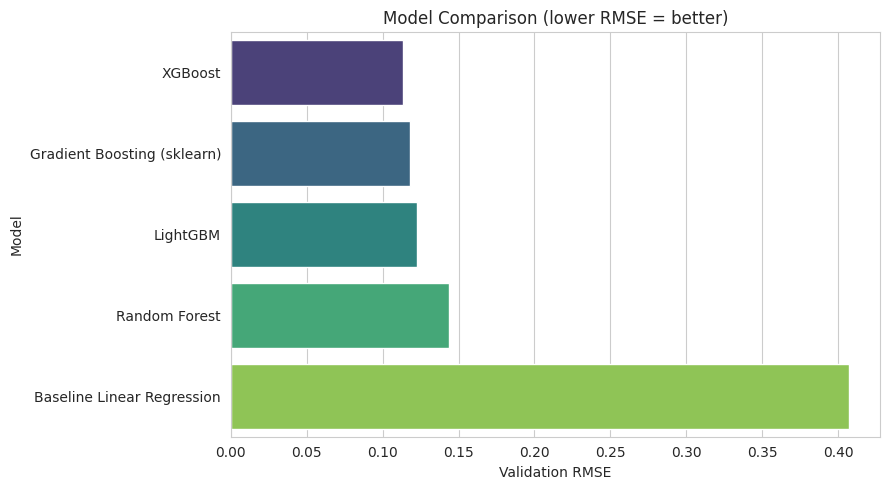

In [42]:

results = pd.DataFrame({
    'Model': ['Baseline Linear Regression', 'Random Forest', 'Gradient Boosting (sklearn)', 'XGBoost', 'LightGBM'],
    'Validation RMSE': [baseline_rmse, rf_rmse, gbr_rmse, xgb_rmse, lgbm_rmse]
}).sort_values('Validation RMSE').reset_index(drop=True)

print(results)

plt.figure(figsize=(9, 5))
sns.barplot(x='Validation RMSE', y='Model', data=results, palette='viridis')
plt.title('Model Comparison (lower RMSE = better)')
plt.tight_layout()
plt.show()



It's normal for the gradient boosting variants to edge out the Random Forest, and for all of them to comfortably beat the 4-feature linear baseline — that gap is a good sanity check that our feature engineering and preprocessing pipeline is adding real value. Exact rankings can vary a bit depending on the random seed and hyperparameters, which is exactly why the next section — tuning — matters.



<a id="tuning"></a>
## 19. Hyperparameter Tuning

**Hyperparameters** are the settings you choose *before* training (like `n_estimators` or `max_depth`) as opposed to the parameters the model *learns from data* (like the split thresholds inside each tree). Picking good hyperparameters is a balancing act known as the **bias-variance tradeoff**:

- Too simple a model (e.g., very few, very shallow trees) → **underfitting** (high bias): the model can't capture real patterns, and both training and validation error are high.
- Too complex a model (e.g., extremely deep trees, huge learning rate, way too many boosting rounds) → **overfitting** (high variance): the model memorizes training-set noise, so training error looks great but validation error is poor.

The key hyperparameters worth tuning for our models:

| Hyperparameter | What it controls |
|---|---|
| `n_estimators` | Number of trees. More trees generally help, up to a point of diminishing (or negative, for boosting) returns. |
| `max_depth` | How deep each tree can grow. Deeper trees capture more complex patterns but overfit more easily. |
| `learning_rate` (boosting only) | How much each new tree is allowed to correct previous errors. Smaller values need more trees but often generalize better. |
| `subsample` / `colsample_bytree` | Fraction of rows/columns randomly used per tree — adds regularization by preventing any single tree from seeing everything. |

Manually trying every combination (a full **grid search**) can be slow with several hyperparameters. **`RandomizedSearchCV`** instead samples a fixed number of random combinations from the ranges you specify, which is often almost as good and much faster — a great default for beginners with limited compute (like Colab's free tier).

We'll tune the sklearn `GradientBoostingRegressor` here as an example; the same pattern applies directly to `XGBRegressor` or `LGBMRegressor` if you want to try tuning those too.


In [43]:

param_distributions = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=RANDOM_SEED),
    param_distributions=param_distributions,
    n_iter=20,           # try 20 random combinations (increase for a more thorough - but slower - search)
    scoring='neg_mean_squared_error',
    cv=3,                # 3-fold CV inside the search to keep runtime reasonable
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best hyperparameters found:")
print(random_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best hyperparameters found:
{'subsample': 0.7, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.1}


In [44]:

best_gbr_model = random_search.best_estimator_
best_gbr_val_pred = best_gbr_model.predict(X_val)

tuned_rmse = np.sqrt(mean_squared_error(y_val, best_gbr_val_pred))
print(f"Tuned Gradient Boosting validation RMSE: {tuned_rmse:.4f}")
print(f"(Untuned Gradient Boosting was:          {gbr_rmse:.4f})")


Tuned Gradient Boosting validation RMSE: 0.1156
(Untuned Gradient Boosting was:          0.1178)



> **Note:** hyperparameter search results can sometimes look only marginally better (or occasionally even a touch worse, due to the extra CV splitting) than a reasonable hand-picked default — that's normal, especially with a modest `n_iter`. Increasing `n_iter`, widening the search ranges, or using a smarter search strategy (like Bayesian optimization via the `optuna` library) tend to close that gap further, at the cost of more compute time.



<a id="importance"></a>
## 20. Feature Importance

Tree-based ensembles are often called "black box" models, but they're actually fairly interpretable in one important way: after training, each model can tell you **how much each feature contributed to reducing prediction error** across all its trees, via `.feature_importances_`. This is useful for:

- **Sanity checking** — do the most important features make real-world sense? (If a meaningless column like a row index ranked #1, that would be a red flag.)
- **Communicating results** — explaining *why* a model predicts what it does, which matters a lot outside of Kaggle, e.g. to a real estate stakeholder.
- **Guiding further feature engineering** — if `TotalSF` (something we engineered) ranks highly, that's a good signal engineered aggregate features are paying off.


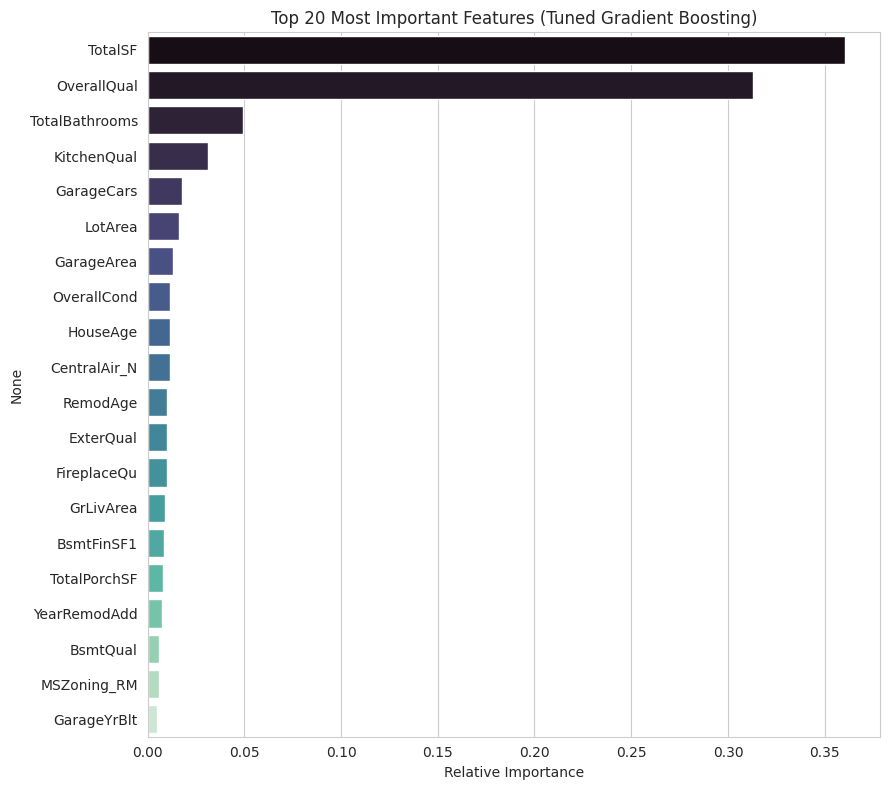

,0
TotalSF,0.360554
OverallQual,0.313097
TotalBathrooms,0.049503
KitchenQual,0.031065
GarageCars,0.017663
LotArea,0.016111
GarageArea,0.013309
OverallCond,0.011805
HouseAge,0.011693
CentralAir_N,0.011541


In [45]:

importances = pd.Series(
    best_gbr_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

top_n = 20
plt.figure(figsize=(9, 8))
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, palette='mako')
plt.title(f'Top {top_n} Most Important Features (Tuned Gradient Boosting)')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

importances.head(top_n)



`OverallQual`, `GrLivArea`, and our engineered `TotalSF` typically dominate — which lines up with both the correlation analysis from Section 6 and basic real-estate intuition (bigger, better-built houses sell for more). Seeing an engineered feature like `TotalSF` rank near the top is a good confirmation that the feature engineering step was worthwhile.



<a id="blending"></a>
## 21. Blending Models

Different model types make different kinds of mistakes — a Random Forest and a Gradient Boosting model won't usually be wrong on exactly the same houses in exactly the same way. **Blending** (or blended ensembling) simply averages multiple models' predictions together. If the models' errors are reasonably uncorrelated, this averaging tends to cancel out some of each model's individual mistakes, often producing a blended prediction that's more accurate than any single model alone — a similar idea to why a Random Forest averages many trees, just one level up.

A simple starting point is an equal-weighted average of two or three of your best, most different models.


In [46]:

blended_val_pred = 0.5 * rf_val_pred + 0.5 * best_gbr_val_pred

blend_rmse = np.sqrt(mean_squared_error(y_val, blended_val_pred))

print(f"Random Forest alone:              {rf_rmse:.4f}")
print(f"Tuned Gradient Boosting alone:     {tuned_rmse:.4f}")
print(f"50/50 Blend of the two:           {blend_rmse:.4f}")


Random Forest alone:              0.1439
Tuned Gradient Boosting alone:     0.1156
50/50 Blend of the two:           0.1251



If the blend's RMSE beats both individual models, that confirms the two models really were making somewhat different kinds of errors. If it doesn't, that's fine too — it usually means the two models are too similar to each other for blending to add much. Feel free to experiment with different weights (e.g., `0.3 * rf + 0.7 * gbr`) or add XGBoost/LightGBM into the mix; whichever combination gives you the best validation RMSE is the one to carry forward.



<a id="final"></a>
## 22. Retraining on Full Data & Predicting on the Test Set

So far, every model has been trained on `X_train` (80% of the training data), holding back `X_val` (20%) purely for honest evaluation. That validation split served its purpose — helping us compare models and tune hyperparameters — but now that we've settled on an approach, **holding back 20% of our data is pure waste** when it comes to making our best possible final predictions. More training data almost always helps a model generalize better.

So, the standard final step: **retrain your chosen model(s) on the *entire* labeled training set** (`X` and `y`, not just `X_train`/`y_train`), using whatever hyperparameters worked best during validation. Only *then* do we predict on the real, unlabeled Kaggle test set (`X_test`).


In [47]:

# Retrain our two chosen models on ALL available training data (not just the 80% split)
final_rf_model = RandomForestRegressor(
    n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1
)
final_rf_model.fit(X, y)

final_gbr_model = GradientBoostingRegressor(**random_search.best_params_, random_state=RANDOM_SEED)
final_gbr_model.fit(X, y)

print("Both models retrained on the full training set.")


Both models retrained on the full training set.


In [48]:

# Predict on the real Kaggle test set (still in log-price scale for now)
rf_test_pred_log = final_rf_model.predict(X_test)
gbr_test_pred_log = final_gbr_model.predict(X_test)

# Blend the same way we validated above
blended_test_pred_log = 0.5 * rf_test_pred_log + 0.5 * gbr_test_pred_log

# Reverse the log1p transform from Section 4 to get back to actual dollar predictions
final_predictions = np.expm1(blended_test_pred_log)

print("Sample of final dollar predictions:")
print(np.round(final_predictions[:10], 2))


Sample of final dollar predictions:
[127361.02 160302.72 179300.32 187987.77 189528.09 179803.52 174921.79
 170165.84 188392.11 123270.97]
